In [1]:
import pandas as pd
from matplotlib_venn import venn3
from matplotlib_venn import venn3_unweighted
import matplotlib.pyplot as plt

In [2]:
intron_up = pd.read_csv('/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_introns_irnaseqCM.txt', sep="\t")
intron_down = pd.read_csv('/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_introns_irnaseqCM.txt', sep="\t")
exon_up = pd.read_csv('/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_exons_irnaseqCM.txt', sep="\t")
exon_down = pd.read_csv('/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_exons_irnaseqCM.txt', sep="\t")

In [3]:
intron_genes = set(intron_up['ensembl']) | set(intron_down['ensembl'])
exon_genes = set(exon_up['ensembl']) | set(exon_down['ensembl'])

In [4]:
common_genes = intron_genes & exon_genes

In [5]:
common_genes

{'ACAP3', 'ALS2CL', 'DGKQ', 'DVL1', 'HSPA5', 'MICALL2', 'SPTBN5', 'WDR90'}

In [6]:
len(common_genes)

8

In [7]:
print(f"Number of common genes: {len(common_genes)}")

Number of common genes: 8


In [8]:
# Load the new DESeq2 results
up_deseq = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt", sep="\t")
down_deseq = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt", sep="\t")

# Use your previous sets from intron+exon DE
irnaseq_genes = intron_genes | exon_genes

# Use HGNC symbols for DESeq2 gene sets
deseq_genes = set(up_deseq['hgnc_symbol']) | set(down_deseq['hgnc_symbol'])

#compare
common_genes = deseq_genes & irnaseq_genes
only_in_deseq = deseq_genes - irnaseq_genes
only_in_irnaseq = irnaseq_genes - deseq_genes

# Output
print(f"Common genes: {len(common_genes)}")
print(f"Only in DESeq2: {len(only_in_deseq)}")
print(f"Only in iRNA-seq: {len(only_in_irnaseq)}")

Common genes: 103
Only in DESeq2: 150
Only in iRNA-seq: 74


#### Making the venn diagram

In [9]:
# Example: Upregulated sets
up_deseq = set(up_deseq['hgnc_symbol'])
up_exon = set(exon_up['ensembl'])
up_intron = set(intron_up['ensembl'])

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


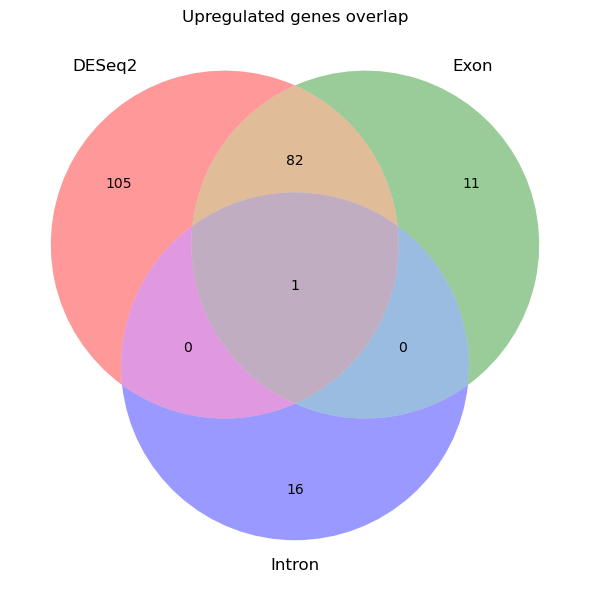

In [10]:
# Venn diagram with equal-sized circles
plt.figure(figsize=(6,6))
venn3_unweighted([up_deseq, up_exon, up_intron], set_labels=('DESeq2', 'Exon', 'Intron'))
plt.title('Upregulated genes overlap')
plt.tight_layout()
plt.show()

In [11]:
# Example: downregulated sets
down_deseq = set(down_deseq['hgnc_symbol'])
down_exon = set(exon_down['ensembl'])
down_intron = set(intron_down['ensembl'])

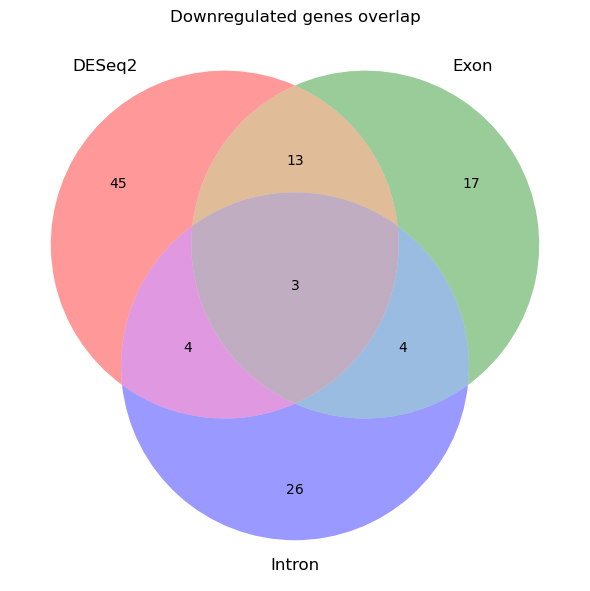

In [12]:
# Venn diagram with equal-sized circles
plt.figure(figsize=(6,6))
venn3_unweighted([down_deseq, down_exon, down_intron], set_labels=('DESeq2', 'Exon', 'Intron'))
plt.title('Downregulated genes overlap')
plt.tight_layout()
plt.show()

In [13]:
mega_upregulated = list(up_deseq | up_exon | up_intron)
len(mega_upregulated)
mup = pd.DataFrame(mega_upregulated, columns=["gene"])
mup.to_csv("mega_upregulated.tsv", sep="\t", index=False, header=False)

In [14]:
mega_downregulated = list(down_deseq | down_exon | down_intron)
len(mega_downregulated)
mdr = pd.DataFrame(mega_downregulated, columns=["gene"])
mdr.to_csv("mega_downregulated.tsv", sep="\t", index=False, header=False)

# GO

#### intron_up

In [15]:
## Running gprofiler to identify enriched processes among significant genes

# %matplotlib inline
# %config InlineBackend.figure_format='retina' # mac
%load_ext autoreload
%autoreload 2
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt


In [16]:
intron_up

,ensembl,log2FC
0,OR51B5,1.687818
1,SYCE2,1.348436
2,SMAD9,1.152076
3,C11orf91,1.469017
4,MMP24-AS1-EDEM2,0.669093
5,POLR1C,0.909623
6,POLR2F,0.772115
7,ARHGEF4,0.715679
8,FAT1,0.623353
9,HSPA5,0.803862


In [17]:
# read in an example gene list
intron_up.drop("log2FC", axis=1).head()

,ensembl
0,OR51B5
1,SYCE2
2,SMAD9
3,C11orf91
4,MMP24-AS1-EDEM2


In [18]:
glist = intron_up["ensembl"].str.strip().to_list()
print(glist[:10])

['OR51B5', 'SYCE2', 'SMAD9', 'C11orf91', 'MMP24-AS1-EDEM2', 'POLR1C', 'POLR2F', 'ARHGEF4', 'FAT1', 'HSPA5']


In [19]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=intron_up, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human'], # are there better updated datasets?
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [20]:
# obj.results stores all results
enr.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,DNA Repair,2/150,0.007058,0.056464,0,0,17.869369,88.517477,POLR1C;POLR2F
1,MSigDB_Hallmark_2020,Unfolded Protein Response,1/113,0.091864,0.157114,0,0,11.088728,26.473788,HSPA5
2,MSigDB_Hallmark_2020,Hypoxia,1/200,0.157114,0.157114,0,0,6.213568,11.499956,HSPA5
3,MSigDB_Hallmark_2020,Oxidative Phosphorylation,1/200,0.157114,0.157114,0,0,6.213568,11.499956,POLR2F
4,MSigDB_Hallmark_2020,Glycolysis,1/200,0.157114,0.157114,0,0,6.213568,11.499956,HSPA5
5,MSigDB_Hallmark_2020,p53 Pathway,1/200,0.157114,0.157114,0,0,6.213568,11.499956,CSRNP2
6,MSigDB_Hallmark_2020,Complement,1/200,0.157114,0.157114,0,0,6.213568,11.499956,HSPA5
7,MSigDB_Hallmark_2020,mTORC1 Signaling,1/200,0.157114,0.157114,0,0,6.213568,11.499956,HSPA5
8,KEGG_2021_Human,RNA polymerase,2/31,0.000312,0.004986,0,0,91.742529,740.694048,POLR1C;POLR2F
9,KEGG_2021_Human,Cytosolic DNA-sensing pathway,2/63,0.001288,0.010306,0,0,43.545355,289.773017,POLR1C;POLR2F


In [21]:
# simple plotting function
from gseapy import barplot, dotplot

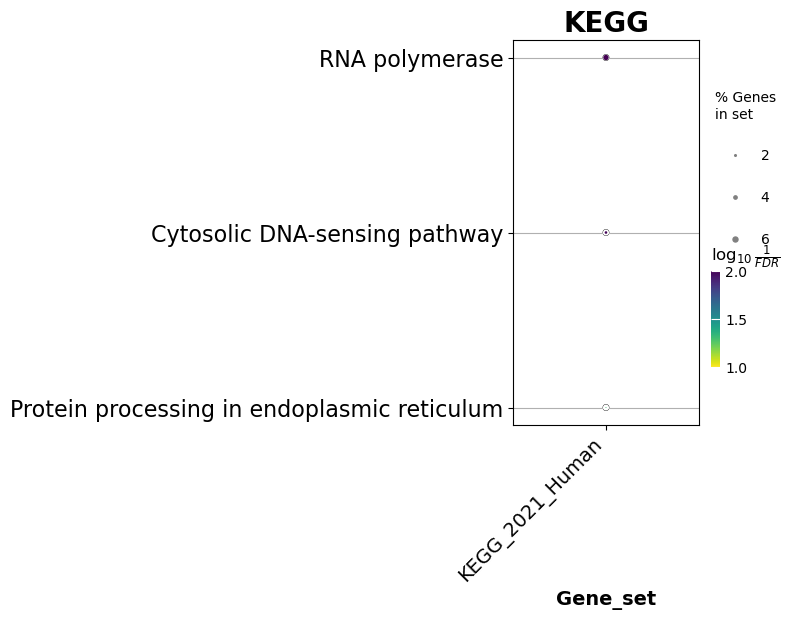

In [22]:
# categorical scatterplot
ax = dotplot(enr.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=10,
              top_term=5,
              figsize=(3,5),
              title = "KEGG",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [23]:
### Not great

In [24]:
import gseapy as gp

libs = gp.get_library_name()  # Fetch all available gene set libraries
print(libs)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency_CellLines_2023', 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019', 'DepMap_WG_C

In [25]:
import pandas as pd
import gseapy as gp

def run_gseapy_enrichment(file_path, gene_col="ensembl", sep="\t", gene_sets=None, outdir="gseapy_results", top_term_plot=True):
    """
    Run Enrichr-based functional enrichment using GSEApy.

    Parameters:
        file_path (str): Path to CSV/TSV file with gene symbols.
        gene_col (str): Column name containing gene symbols (HGNC).
        sep (str): Delimiter, default '\t' for TSV.
        gene_sets (list or str): Enrichr library name(s). e.g., 'KEGG_2021_Human'
        outdir (str): Output directory for results and plots.
        top_term_plot (bool): Whether to generate a barplot of top terms.

    Returns:
        DataFrame: Enrichment results table
    """
    # Load and preprocess gene list
    df = pd.read_csv(file_path, sep=sep)
    genes = df[gene_col].dropna().astype(str).str.upper().tolist()

    # Default gene sets if not provided
    if gene_sets is None:
        gene_sets = ["KEGG_2021_Human", "MSigDB_Hallmark_2020", "GO_Biological_Process_2021"]

    # Run enrichment
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=gene_sets,
        organism="Human",
        outdir=outdir,
        cutoff=0.2,
        no_plot=not top_term_plot,
    )

    return enr.results


                                  Term  Adjusted P-value Overlap  \
0                             Lysosome          0.005209   6/128   
1                    Adherens junction          0.029003    4/71   
2              Cell adhesion molecules          0.037114   5/148   
3               FoxO signaling pathway          0.141183   4/131   
4  Antigen processing and presentation          0.168982    3/78   

                             Genes  
0  SORT1;LAMP3;PSAP;TPP1;CTSD;LGMN  
1         PTPRF;EGFR;NECTIN2;IGF1R  
2    SDC3;HLA-C;NEO1;PTPRF;NECTIN2  
3             PLK1;EGFR;PCK2;IGF1R  
4                 HSPA5;HLA-C;LGMN  


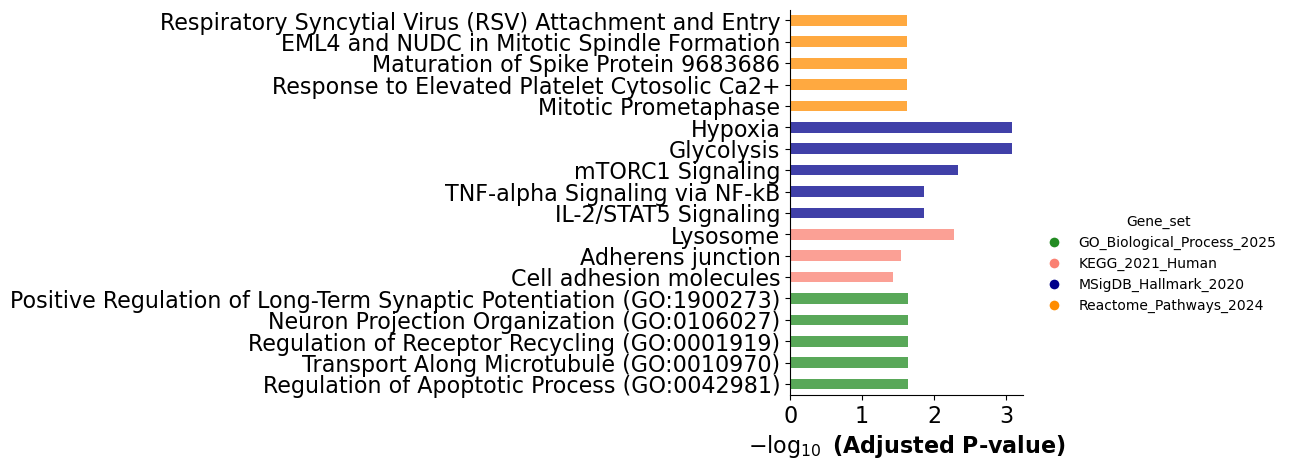

In [26]:
result_df = run_gseapy_enrichment(
    file_path="upregulated_genes_exons_irnaseqCM.txt",
    gene_col="ensembl",
    sep="\t",
        gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2025",
        "Reactome_Pathways_2024",
        "MSigDB_Hallmark_2020"
    ]
)


# View top enriched terms
print(result_df[['Term', 'Adjusted P-value', 'Overlap', 'Genes']].head())

# Save results
#result_df.to_csv("intron_up_enrichment_gseapy.csv", index=False)

# categorical scatterplot
ax = barplot(result_df,
              column="Adjusted P-value",
              group='Gene_set',
              size=10,
              top_term=5,
              figsize=(3,5),
              color={
                  'KEGG_2021_Human': 'salmon',
                  'MSigDB_Hallmark_2020': 'darkblue',
                  'GO_Biological_Process_2025': 'forestgreen',
                  'Reactome_Pathways_2024': 'darkorange'
              }
)


In [27]:
# run with p =

result_df = run_gseapy_enrichment(
    file_path="downregulated_genes_exons_irnaseqCM.txt",
    gene_col="ensembl",
    sep="\t",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2025",
        "Reactome_Pathways_2024",
        "MSigDB_Hallmark_2020"
    ]
)

# View top enriched terms
print(result_df[['Term', 'Adjusted P-value', 'Overlap', 'Genes']].head())

# Save results
#result_df.to_csv("intron_up_enrichment_gseapy.csv", index=False)

# categorical scatterplot
# categorical scatterplot
ax = barplot(result_df,
              column="Adjusted P-value",
              group='Gene_set',
              size=10,
              top_term=5,
              figsize=(3,5),
              color={
                  'KEGG_2021_Human': 'salmon',
                  'MSigDB_Hallmark_2020': 'darkblue',
                  'GO_Biological_Process_2025': 'forestgreen',
                  'Reactome_Pathways_2024': 'darkorange'
              }
)

ValueError: Warning: No enrich terms when cutoff = 0.2

                                          Term  Adjusted P-value Overlap  \
0                               RNA polymerase          0.004986    2/31   
1                Cytosolic DNA-sensing pathway          0.010306    2/63   
2  Protein processing in endoplasmic reticulum          0.048452   2/171   
3                               Protein export          0.077515    1/23   
4                    Thyroid hormone synthesis          0.171456    1/75   

                   Genes  
0          POLR1C;POLR2F  
1          POLR1C;POLR2F  
2  HSPA5;MMP24-AS1-EDEM2  
3                  HSPA5  
4                  HSPA5  


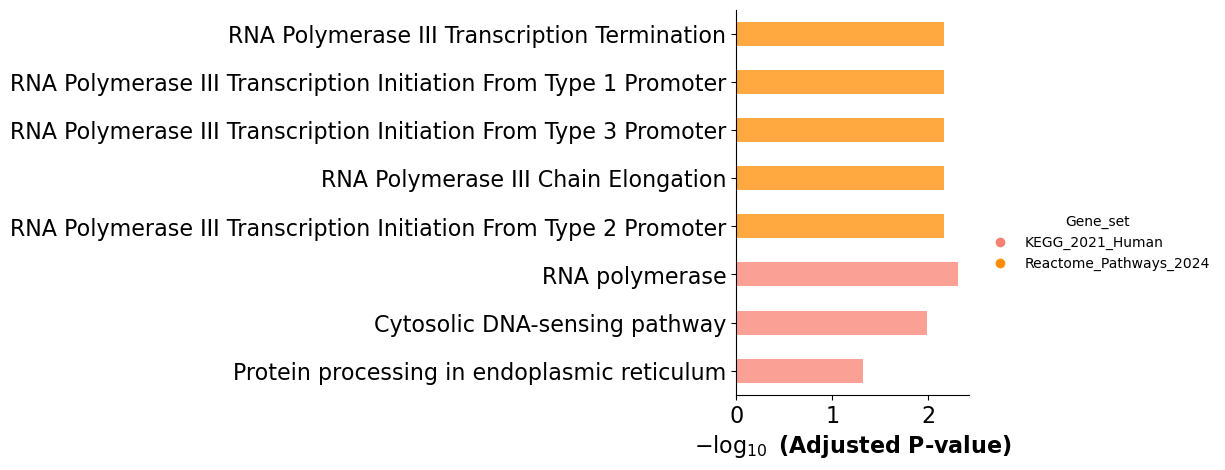

In [ ]:
result_df = run_gseapy_enrichment(
    file_path="upregulated_genes_introns_irnaseqCM.txt",
    gene_col="ensembl",
    sep="\t",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2025",
        "Reactome_Pathways_2024",
        "MSigDB_Hallmark_2020"
    ]
)

# View top enriched terms
print(result_df[['Term', 'Adjusted P-value', 'Overlap', 'Genes']].head())

# Save results
#result_df.to_csv("intron_up_enrichment_gseapy.csv", index=False)

# categorical scatterplot
# categorical scatterplot
ax = barplot(result_df,
              column="Adjusted P-value",
              group='Gene_set',
              size=10,
              top_term=5,
              figsize=(3,5),
              color={
                  'KEGG_2021_Human': 'salmon',
                  'MSigDB_Hallmark_2020': 'darkblue',
                  'GO_Biological_Process_2025': 'forestgreen',
                  'Reactome_Pathways_2024': 'darkorange'
              }
)

                             Term  Adjusted P-value Overlap  \
0      PI3K-Akt signaling pathway          0.000441   7/354   
1          Small cell lung cancer          0.001627    4/92   
2              Pathways in cancer          0.002028   7/531   
3                  Gastric cancer          0.005325   4/149   
4  Human papillomavirus infection          0.008973   5/331   

                                   Genes  
0  LAMA5;RXRA;CCNE1;MYB;AKT1;ITGB8;EFNA5  
1                  LAMA5;RXRA;CCNE1;AKT1  
2  JAG2;LAMA5;RXRA;MECOM;CCNE1;DVL1;AKT1  
3                   RXRA;CCNE1;DVL1;AKT1  
4            LAMA5;CCNE1;DVL1;AKT1;ITGB8  


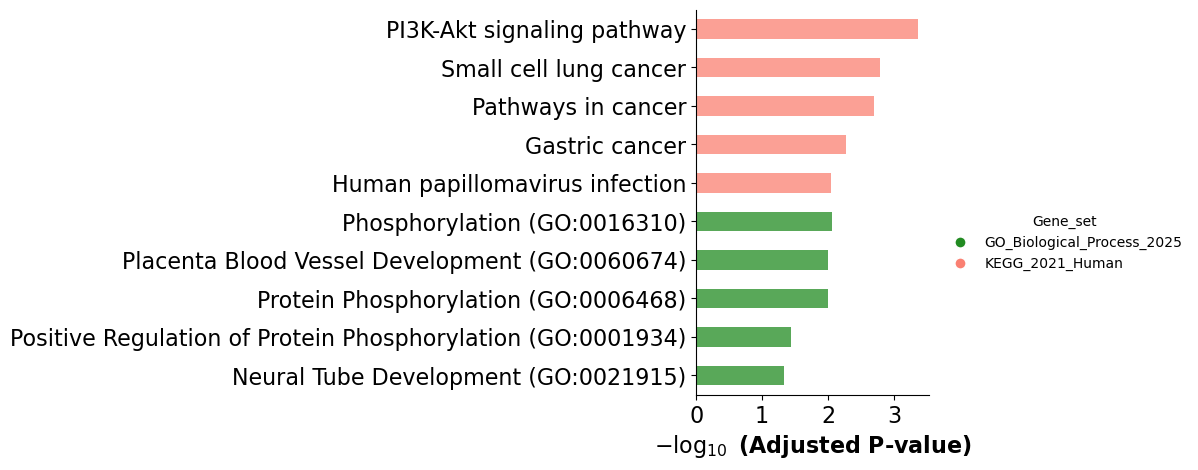

In [ ]:
result_df = run_gseapy_enrichment(
    file_path="downregulated_genes_introns_irnaseqCM.txt",
    gene_col="ensembl",
    sep="\t",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2025",
        "Reactome_Pathways_2024",
        "MSigDB_Hallmark_2020"
    ]
)

# View top enriched terms
print(result_df[['Term', 'Adjusted P-value', 'Overlap', 'Genes']].head())

# Save results
#result_df.to_csv("intron_up_enrichment_gseapy.csv", index=False)

# categorical scatterplot
# categorical scatterplot
ax = barplot(result_df,
              column="Adjusted P-value",
              group='Gene_set',
              size=10,
              top_term=5,
              figsize=(3,5),
              color={
                  'KEGG_2021_Human': 'salmon',
                  'MSigDB_Hallmark_2020': 'darkblue',
                  'GO_Biological_Process_2025': 'forestgreen',
                  'Reactome_Pathways_2024': 'darkorange'
              }
)

In [ ]:
# Export shared genes between intron and exon
pd.DataFrame({'ensembl': list(common_genes)}).to_csv("common_intron_exon_genes.csv", index=False)

---

In [ ]:
# switch to R env here

## Cluster profiler

### GO over-representation analysis

In [ ]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)

run_go_enrichment_from_file <- function(filepath, delim = "\t", symbol_col = "ensembl") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- enrichGO(
    gene          = converted$entrezgene_id,
    OrgDb         = org.Hs.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.1,
    readable      = TRUE
  )

  return(ego)
}




clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:biomaRt’:

    select


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, 

In [ ]:
ego_result_up_introns <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_introns_irnaseqCM.txt")

# View results
as.data.frame(ego_result_up_introns)

# Save to CSV
#if (!is.null(ego_result)) {
#  write.csv(as.data.frame(ego_result), "intron_up_GO_results.csv", row.names = FALSE)
#}

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


In [ ]:
ego_result_up_exons <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_exons_irnaseqCM.txt")

# View results
as.data.frame(ego_result_up_exons)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0031103,GO:0031103,axon regeneration,5/88,52/18870,4.300303e-06,0.005684549,0.004737461,DAG1/GRN/IGF1R/NEO1/PTPRF,5
GO:0031102,GO:0031102,neuron projection regeneration,5/88,58/18870,7.416922e-06,0.005684549,0.004737461,DAG1/GRN/IGF1R/NEO1/PTPRF,5
GO:0032731,GO:0032731,positive regulation of interleukin-1 beta production,5/88,62/18870,1.032215e-05,0.005684549,0.004737461,APP/EGR1/HK1/HSPB1/MYD88,5
GO:0048679,GO:0048679,regulation of axon regeneration,4/88,30/18870,1.102963e-05,0.005684549,0.004737461,GRN/IGF1R/NEO1/PTPRF,4
GO:0070570,GO:0070570,regulation of neuron projection regeneration,4/88,32/18870,1.437011e-05,0.005684549,0.004737461,GRN/IGF1R/NEO1/PTPRF,4
GO:0071260,GO:0071260,cellular response to mechanical stimulus,5/88,72/18870,2.151660e-05,0.005684549,0.004737461,BAG3/DAG1/IGF1R/MYD88/SLC9A1,5
GO:0021782,GO:0021782,glial cell development,6/88,122/18870,2.269420e-05,0.005684549,0.004737461,APP/DAG1/GRN/LDLR/NDRG1/PHGDH,6
GO:0032732,GO:0032732,positive regulation of interleukin-1 production,5/88,73/18870,2.301437e-05,0.005684549,0.004737461,APP/EGR1/HK1/HSPB1/MYD88,5
GO:0043112,GO:0043112,receptor metabolic process,5/88,73/18870,2.301437e-05,0.005684549,0.004737461,CTSD/ECE1/LDLR/LGMN/TBC1D16,5


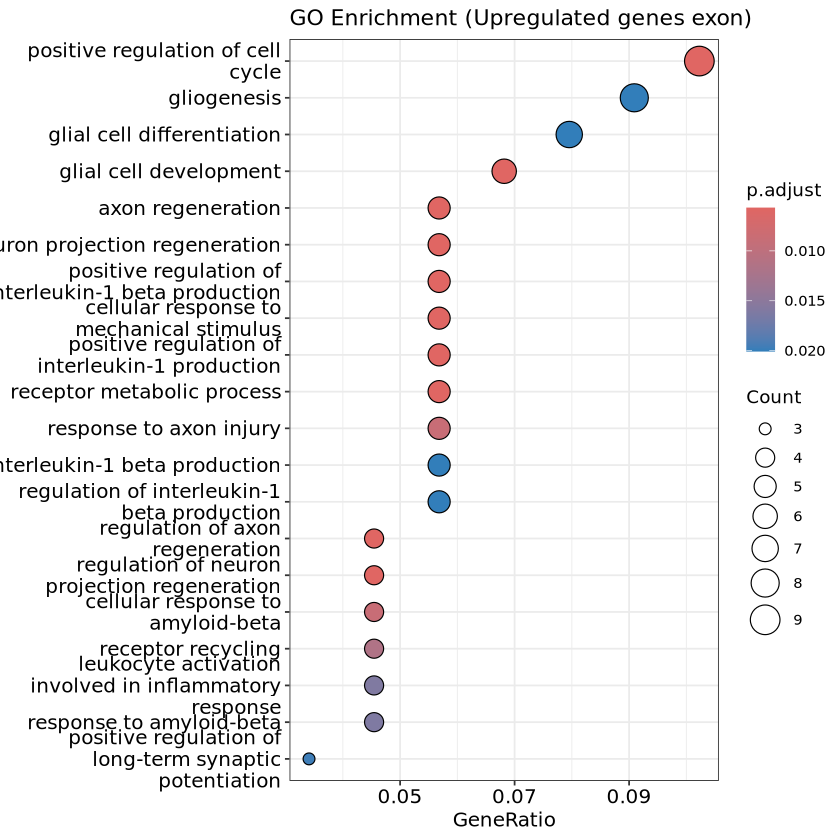

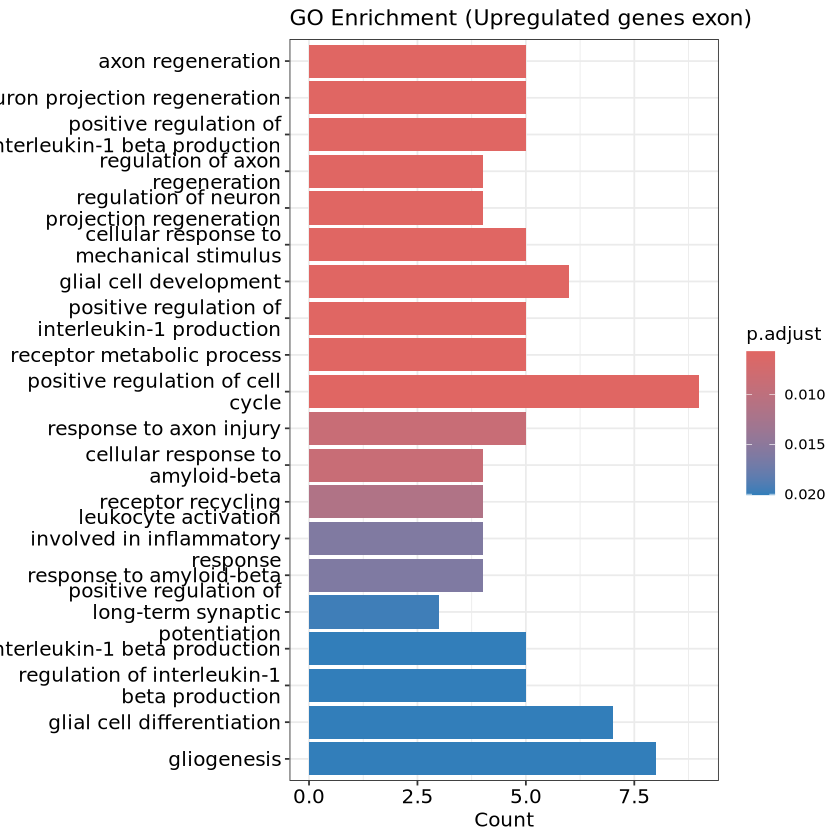

In [ ]:
dotplot(ego_result_up_exons, showCategory = 20, title = "GO Enrichment (Upregulated genes exon)")
barplot(ego_result_up_exons, showCategory = 20, title = "GO Enrichment (Upregulated genes exon)")

In [ ]:
ego_result_down_introns <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_introns_irnaseqCM.txt")

# View results
as.data.frame(ego_result_down_introns)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0031589,GO:0031589,cell-substrate adhesion,7/35,356/18870,3.421675e-06,0.004708225,0.003673798,EFNA5/GAS6/ITGB8/LAMA5/MICALL2/PKD1/UNC13D,7
GO:0060674,GO:0060674,placenta blood vessel development,3/35,31/18870,2.535563e-05,0.015716947,0.012263836,AKT1/ITGB8/PKD1,3
GO:0034446,GO:0034446,substrate adhesion-dependent cell spreading,4/35,100/18870,3.426660e-05,0.015716947,0.012263836,EFNA5/LAMA5/MICALL2/UNC13D,4
GO:0032006,GO:0032006,regulation of TOR signaling,4/35,147/18870,1.534009e-04,0.052769896,0.041176020,AKT1/DGKQ/GAS6/TELO2,4
GO:0031929,GO:0031929,TOR signaling,4/35,167/18870,2.501358e-04,0.064584683,0.050395025,AKT1/DGKQ/GAS6/TELO2,4
GO:0032008,GO:0032008,positive regulation of TOR signaling,3/35,69/18870,2.816193e-04,0.064584683,0.050395025,AKT1/GAS6/TELO2,3
GO:0045737,GO:0045737,positive regulation of cyclin-dependent protein serine/threonine kinase activity,2/35,15/18870,3.456470e-04,0.067944331,0.053016537,AKT1/PKD1,2
GO:0000079,GO:0000079,regulation of cyclin-dependent protein serine/threonine kinase activity,3/35,82/18870,4.682251e-04,0.071582694,0.055855529,AKT1/CCNE1/PKD1,3
GO:1904031,GO:1904031,positive regulation of cyclin-dependent protein kinase activity,2/35,18/18870,5.019000e-04,0.071582694,0.055855529,AKT1/PKD1,2


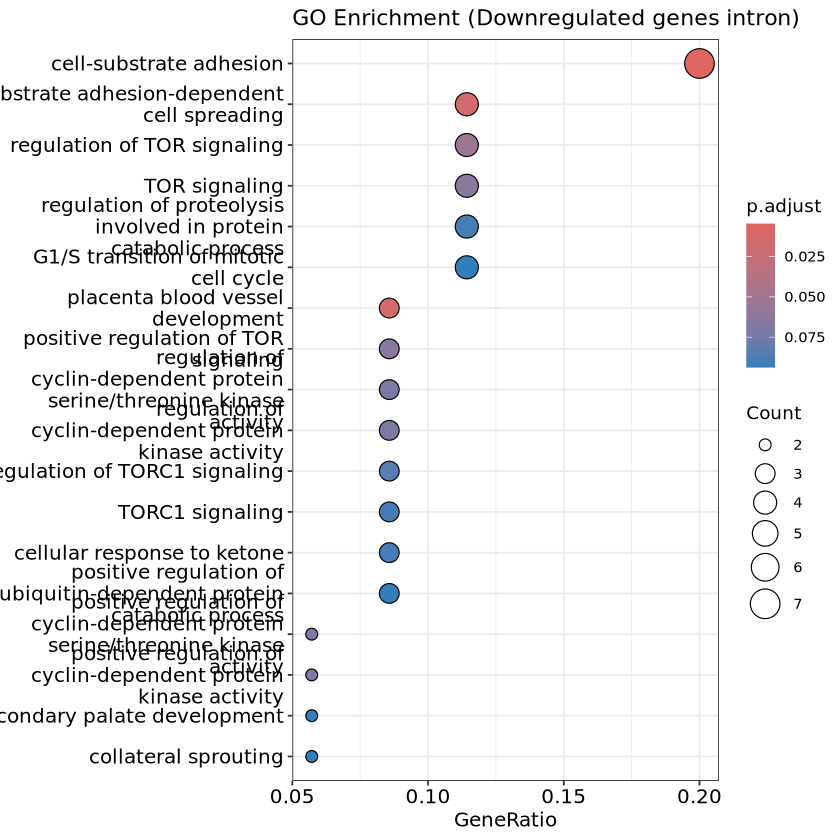

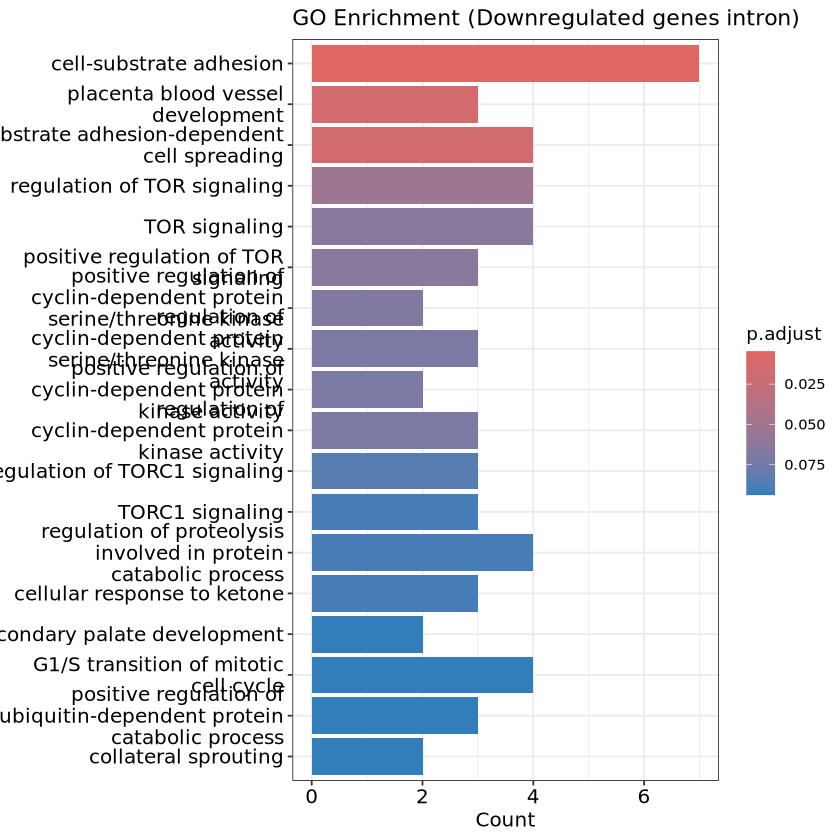

In [ ]:
dotplot(ego_result_down_introns, showCategory = 20, title = "GO Enrichment (Downregulated genes intron)")
barplot(ego_result_down_introns, showCategory = 20, title = "GO Enrichment (Downregulated genes intron)")

In [ ]:
ego_result_down_exons <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_exons_irnaseqCM.txt")

# View results
as.data.frame(ego_result_down_exons)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


In [ ]:
ego_result_common_genes <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/common_intron_exon_genes.csv")

# View results
as.data.frame(ego_result_common_genes)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0031103,GO:0031103,axon regeneration,5/95,52/18870,6.268366e-06,0.008786223,0.007484187,DAG1/GRN/IGF1R/NEO1/PTPRF,5
GO:0031102,GO:0031102,neuron projection regeneration,5/95,58/18870,1.079139e-05,0.008786223,0.007484187,DAG1/GRN/IGF1R/NEO1/PTPRF,5
GO:0048679,GO:0048679,regulation of axon regeneration,4/95,30/18870,1.494208e-05,0.008786223,0.007484187,GRN/IGF1R/NEO1/PTPRF,4
GO:0032731,GO:0032731,positive regulation of interleukin-1 beta production,5/95,62/18870,1.499995e-05,0.008786223,0.007484187,APP/EGR1/HK1/HSPB1/MYD88,5
GO:0070570,GO:0070570,regulation of neuron projection regeneration,4/95,32/18870,1.945599e-05,0.009117076,0.007766011,GRN/IGF1R/NEO1/PTPRF,4
GO:0071260,GO:0071260,cellular response to mechanical stimulus,5/95,72/18870,3.117171e-05,0.011156481,0.009503196,BAG3/DAG1/IGF1R/MYD88/SLC9A1,5
GO:0032732,GO:0032732,positive regulation of interleukin-1 production,5/95,73/18870,3.333136e-05,0.011156481,0.009503196,APP/EGR1/HK1/HSPB1/MYD88,5
GO:0045931,GO:0045931,positive regulation of mitotic cell cycle,6/95,128/18870,4.594610e-05,0.012310419,0.010486131,APP/CDC20/CDK10/EGFR/LGMN/PPP1R10,6
GO:0045787,GO:0045787,positive regulation of cell cycle,9/95,334/18870,4.728714e-05,0.012310419,0.010486131,APP/CDC20/CDK10/EGFR/FOSL1/IGF1R/INCENP/LGMN/PPP1R10,9


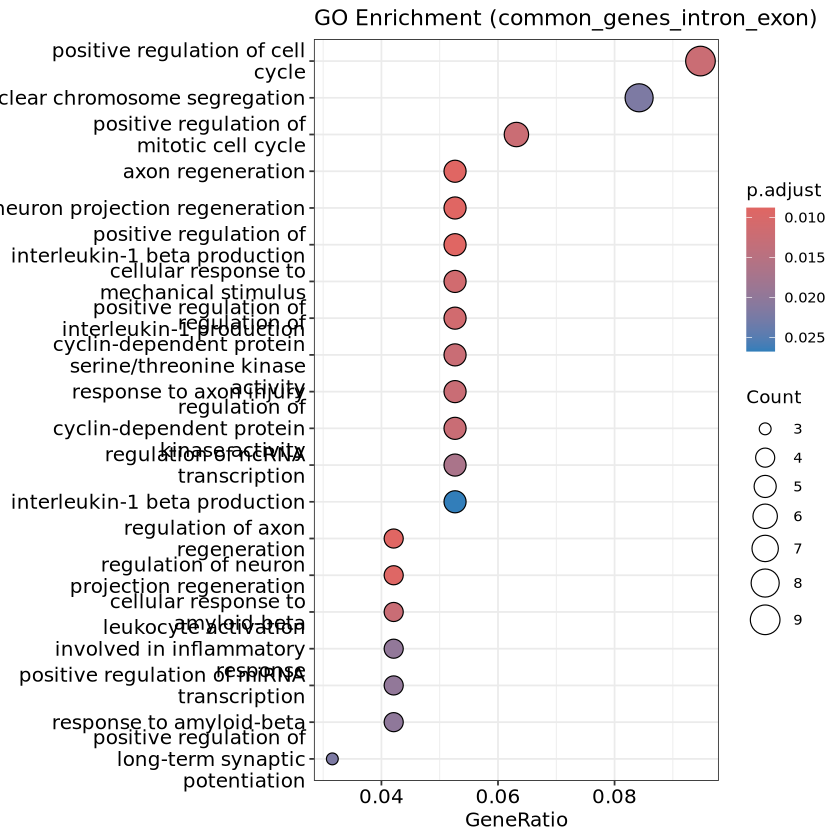

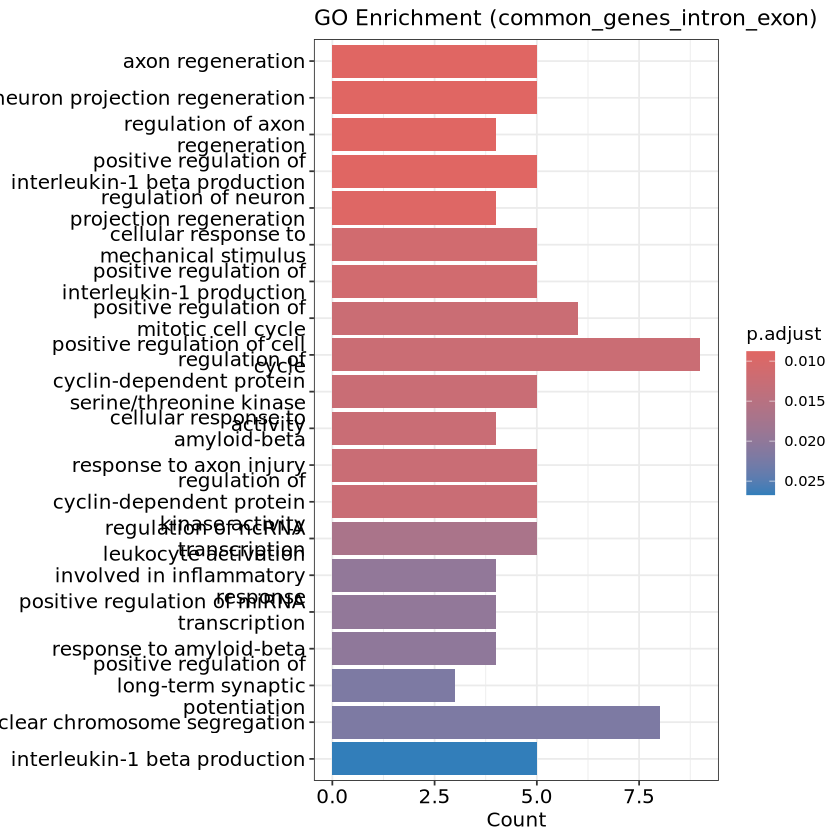

In [ ]:
dotplot(ego_result_common_genes, showCategory = 20, title = "GO Enrichment (common_genes_intron_exon)")
barplot(ego_result_common_genes, showCategory = 20, title = "GO Enrichment (common_genes_intron_exon)")

#### GO classification

In [ ]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)

run_go_groupping_from_file <- function(filepath, delim = "\t", symbol_col = "ensembl") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- groupGO(
    gene     = as.character(converted$entrezgene_id),
    OrgDb    = org.Hs.eg.db,
    ont      = "BP",
    level    = 3,              # Optional: GO hierarchy level (e.g., 3 for broader terms)
    readable = TRUE
  )

  return(ego)
}

In [ ]:
go_classification_up_introns <- run_go_groupping_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_introns_irnaseqCM.txt")

# View results
as.data.frame(go_classification_up_introns)

# Save to CSV
#if (!is.null(go_classification)) {
#  write.csv(as.data.frame(go_classification), "intron_up_GO_results.csv", row.names = FALSE)
#}

,ID,Description,Count,GeneRatio,geneID
,<chr>,<chr>,<int>,<chr>,<chr>
GO:0019953,GO:0019953,sexual reproduction,3,3/17,MEI1/SYCE2/ZDBF2
GO:0019954,GO:0019954,asexual reproduction,0,0/17,
GO:0022414,GO:0022414,reproductive process,3,3/17,MEI1/SYCE2/ZDBF2
GO:0032504,GO:0032504,multicellular organism reproduction,1,1/17,ZDBF2
GO:0032505,GO:0032505,reproduction of a single-celled organism,0,0/17,
GO:0075325,GO:0075325,spore dispersal,0,0/17,
GO:1990277,GO:1990277,parasexual reproduction with cellular fusion,0,0/17,
GO:0001776,GO:0001776,leukocyte homeostasis,0,0/17,
GO:0002200,GO:0002200,somatic diversification of immune receptors,0,0/17,


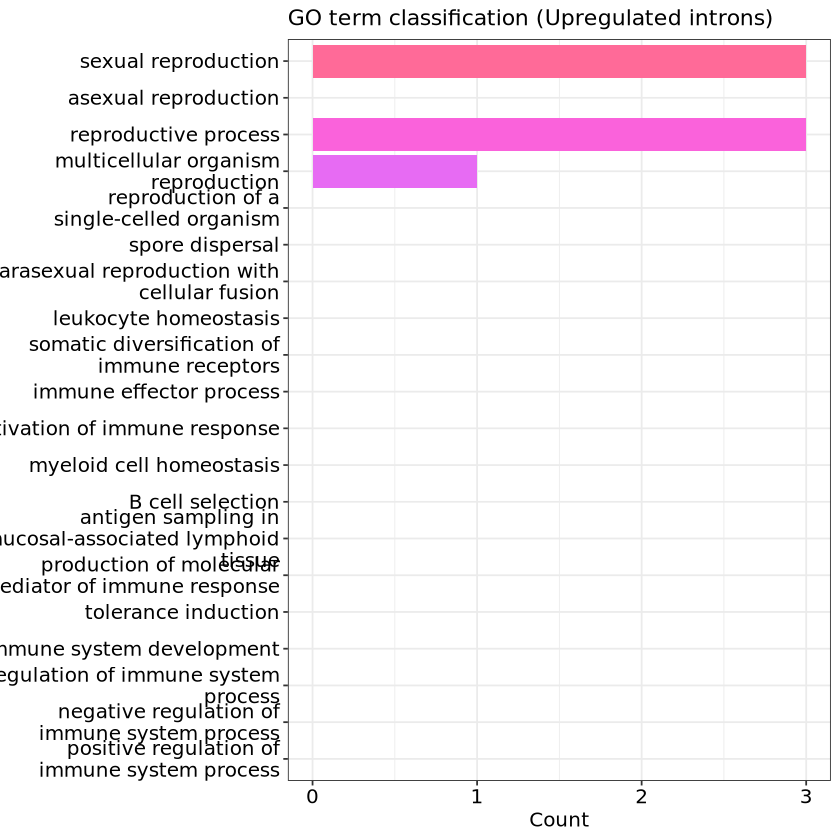

In [ ]:
# Basic barplot
barplot(go_classification_up_introns, showCategory = 20, title = "GO term classification (Upregulated introns)")

In [ ]:
go_classification_up_exons <- run_go_groupping_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_exons_irnaseqCM.txt")

# View resugo_classification)
as.data.frame(go_classification_up_exons)

,ID,Description,Count,GeneRatio,geneID
,<chr>,<chr>,<int>,<chr>,<chr>
GO:0019953,GO:0019953,sexual reproduction,6,6/94,CDC20/FOSL1/INCENP/NCAPD2/NECTIN2/PLK1
GO:0019954,GO:0019954,asexual reproduction,0,0/94,
GO:0022414,GO:0022414,reproductive process,10,10/94,APP/CDC20/EGR1/FOSL1/IGF1R/INCENP/NCAPD2/NECTIN2/PLK1/PSAP
GO:0032504,GO:0032504,multicellular organism reproduction,6,6/94,APP/EGR1/FOSL1/IGF1R/NECTIN2/PLK1
GO:0032505,GO:0032505,reproduction of a single-celled organism,0,0/94,
GO:0075325,GO:0075325,spore dispersal,0,0/94,
GO:1990277,GO:1990277,parasexual reproduction with cellular fusion,0,0/94,
GO:0001776,GO:0001776,leukocyte homeostasis,0,0/94,
GO:0002200,GO:0002200,somatic diversification of immune receptors,0,0/94,


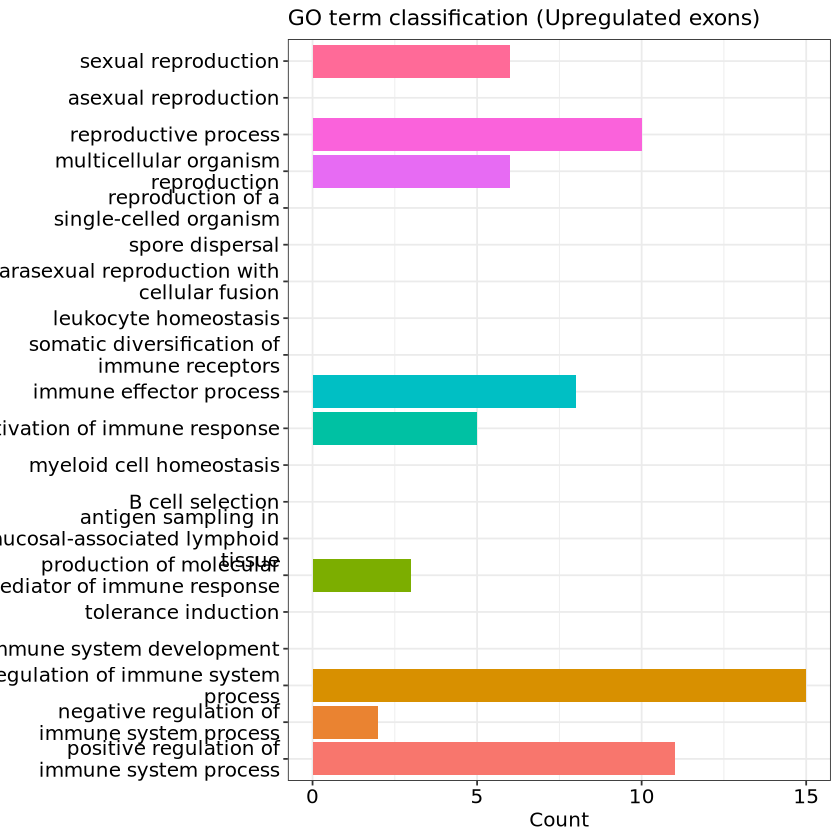

In [ ]:
# Basic barplot
barplot(go_classification_up_exons, showCategory = 20, title = "GO term classification (Upregulated exons)")

In [ ]:
go_classification_down_introns <- run_go_groupping_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_introns_irnaseqCM.txt")

# View results
as.data.frame(go_classification_down_introns)

,ID,Description,Count,GeneRatio,geneID
,<chr>,<chr>,<int>,<chr>,<chr>
GO:0019953,GO:0019953,sexual reproduction,3,3/37,AKT1/CCNE1/JAG2
GO:0019954,GO:0019954,asexual reproduction,0,0/37,
GO:0022414,GO:0022414,reproductive process,5,5/37,AKT1/CCNE1/INTS1/JAG2/PKD1
GO:0032504,GO:0032504,multicellular organism reproduction,2,2/37,AKT1/JAG2
GO:0032505,GO:0032505,reproduction of a single-celled organism,0,0/37,
GO:0075325,GO:0075325,spore dispersal,0,0/37,
GO:1990277,GO:1990277,parasexual reproduction with cellular fusion,0,0/37,
GO:0001776,GO:0001776,leukocyte homeostasis,1,1/37,AKT1
GO:0002200,GO:0002200,somatic diversification of immune receptors,0,0/37,


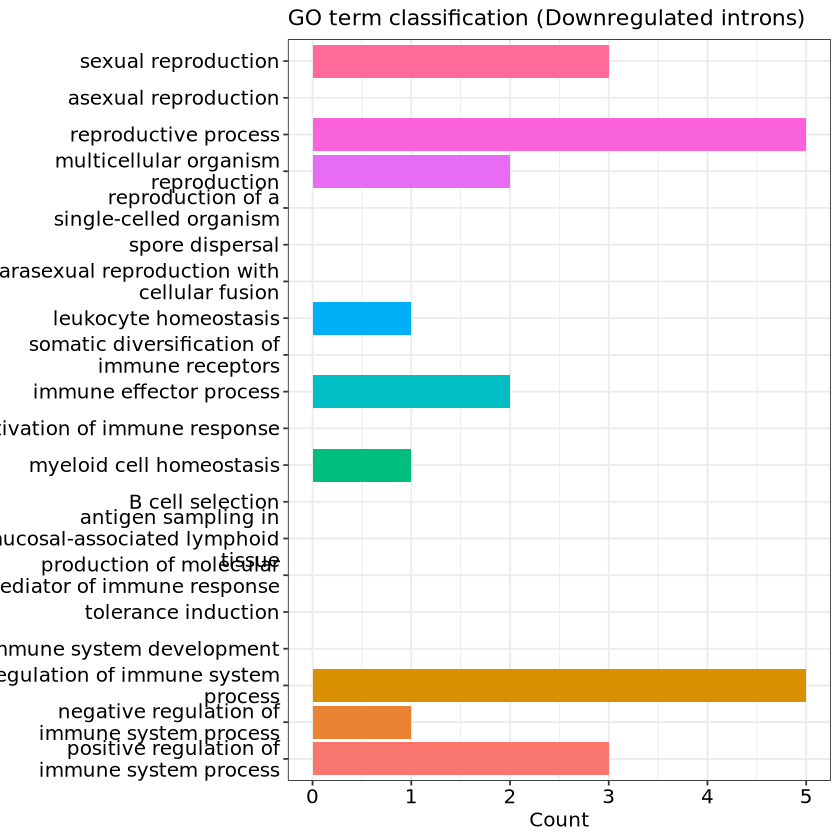

In [ ]:
# Basic barplot
barplot(go_classification_down_introns, showCategory = 20, title = "GO term classification (Downregulated introns)")

In [ ]:
go_classification_down_exons <- run_go_groupping_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_exons_irnaseqCM.txt")

# View results
as.data.frame(go_classification_down_exons)

,ID,Description,Count,GeneRatio,geneID
,<chr>,<chr>,<int>,<chr>,<chr>
GO:0019953,GO:0019953,sexual reproduction,1,1/36,CCNE2
GO:0019954,GO:0019954,asexual reproduction,0,0/36,
GO:0022414,GO:0022414,reproductive process,1,1/36,CCNE2
GO:0032504,GO:0032504,multicellular organism reproduction,0,0/36,
GO:0032505,GO:0032505,reproduction of a single-celled organism,0,0/36,
GO:0075325,GO:0075325,spore dispersal,0,0/36,
GO:1990277,GO:1990277,parasexual reproduction with cellular fusion,0,0/36,
GO:0001776,GO:0001776,leukocyte homeostasis,0,0/36,
GO:0002200,GO:0002200,somatic diversification of immune receptors,0,0/36,


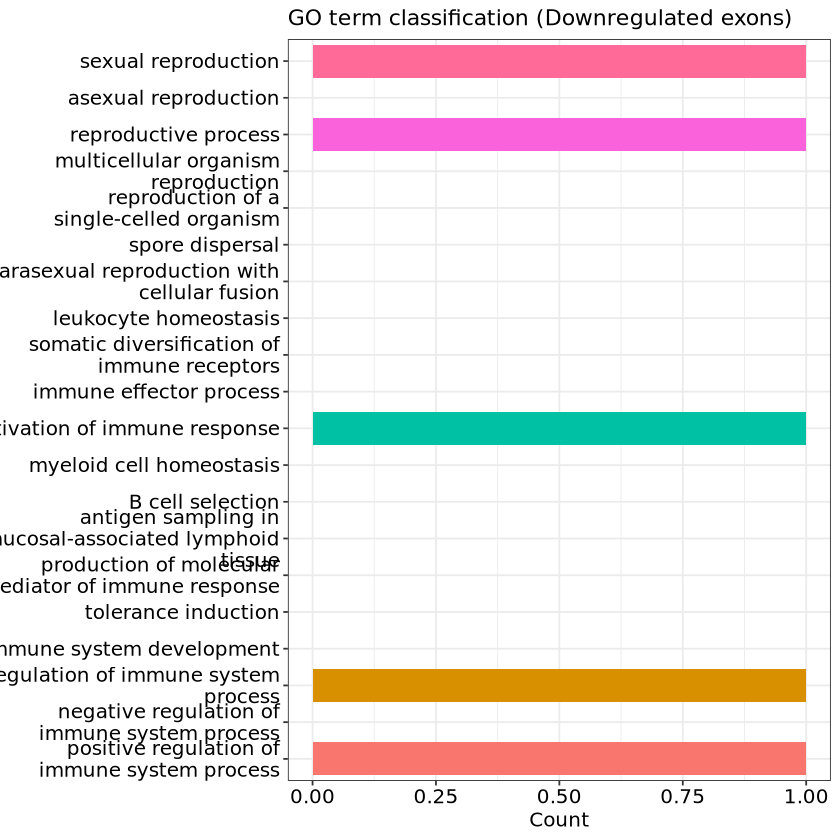

In [ ]:
# Basic barplot
barplot(go_classification_down_exons, showCategory = 20, title = "GO term classification (Downregulated exons)")

In [ ]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)

run_go_enrichment_from_file <- function(filepath, delim = "\t", symbol_col = "hgnc_symbol") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- enrichGO(
    gene          = converted$entrezgene_id,
    OrgDb         = org.Hs.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.1,
    readable      = TRUE
  )

  return(ego)
}

In [ ]:
ego_result_down_deseq <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt")

# View results
as.data.frame(ego_result_down_deseq)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0007127,GO:0007127,meiosis I,4/44,129/18870,0.0002289659,0.05882906,0.05395699,CCNE1/CCNE2/EME2/ING2,4
GO:1902460,GO:1902460,regulation of mesenchymal stem cell proliferation,2/44,10/18870,0.0002362957,0.05882906,0.05395699,CCNE1/LTBP3,2
GO:0061982,GO:0061982,meiosis I cell cycle process,4/44,136/18870,0.0002802105,0.05882906,0.05395699,CCNE1/CCNE2/EME2/ING2,4
GO:0097168,GO:0097168,mesenchymal stem cell proliferation,2/44,11/18870,0.0002883777,0.05882906,0.05395699,CCNE1/LTBP3,2


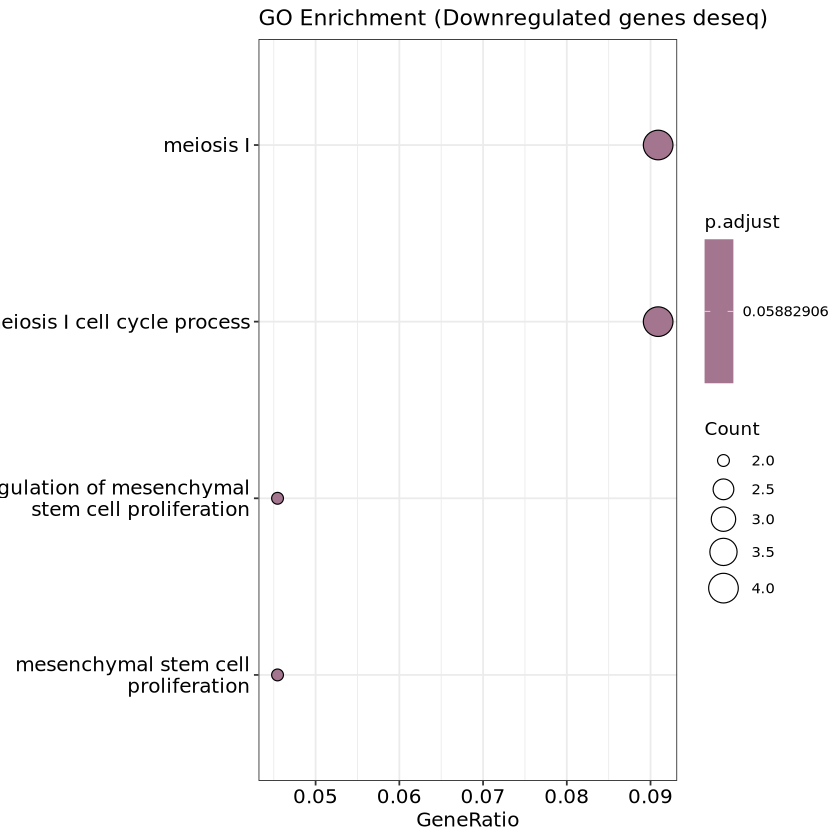

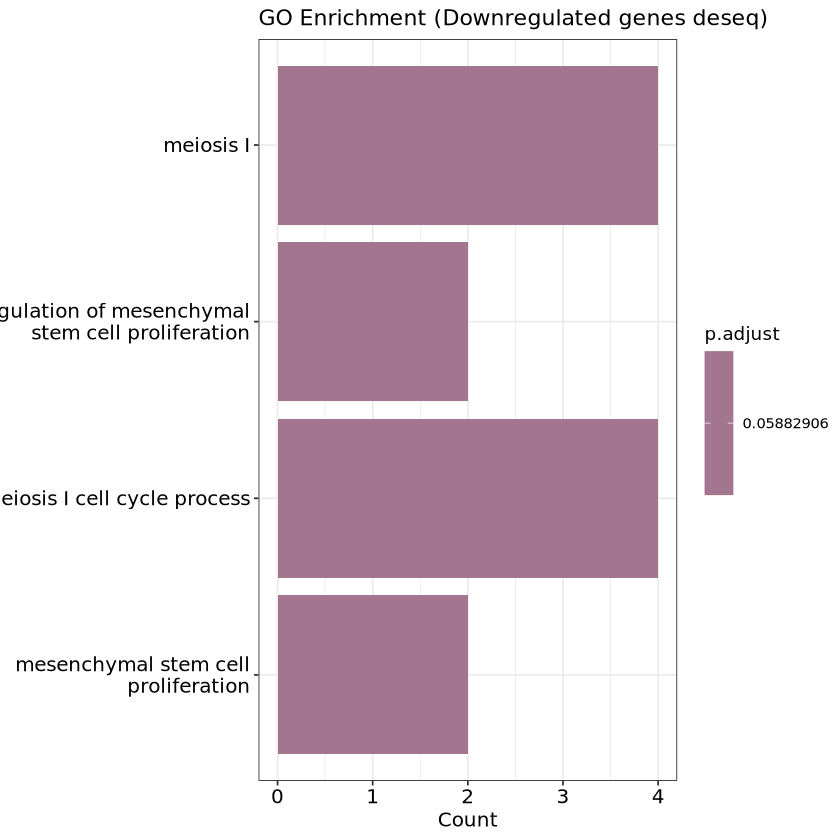

In [ ]:
dotplot(ego_result_down_deseq, showCategory = 20, title = "GO Enrichment (Downregulated genes deseq)")
barplot(ego_result_down_deseq, showCategory = 20, title = "GO Enrichment (Downregulated genes deseq)")

In [ ]:
ego_result_up_deseq <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt")

# View results
as.data.frame(ego_result_up_deseq)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0031103,GO:0031103,axon regeneration,7/175,52/18870,4.924402e-07,0.001669372,0.001310928,DAG1/GRN/IGF1R/KREMEN1/NEO1/PTPRF/TNC,7
GO:0031102,GO:0031102,neuron projection regeneration,7/175,58/18870,1.056178e-06,0.001790222,0.001405829,DAG1/GRN/IGF1R/KREMEN1/NEO1/PTPRF/TNC,7
GO:0001909,GO:0001909,leukocyte mediated cytotoxicity,9/175,140/18870,6.389197e-06,0.004005139,0.003145163,HLA-B/HLA-C/HLA-F/MYD88/NECTIN2/TGFB1/TUBB/TUBB4B/ULBP1,9
GO:0042267,GO:0042267,natural killer cell mediated cytotoxicity,7/175,76/18870,6.675364e-06,0.004005139,0.003145163,HLA-B/HLA-F/NECTIN2/TGFB1/TUBB/TUBB4B/ULBP1,7
GO:0048679,GO:0048679,regulation of axon regeneration,5/175,30/18870,7.650538e-06,0.004005139,0.003145163,GRN/IGF1R/KREMEN1/NEO1/PTPRF,5
GO:0002269,GO:0002269,leukocyte activation involved in inflammatory response,6/175,52/18870,8.346036e-06,0.004005139,0.003145163,APP/CLU/GRN/LDLR/MYD88/NR1D1,6
GO:0002228,GO:0002228,natural killer cell mediated immunity,7/175,79/18870,8.647009e-06,0.004005139,0.003145163,HLA-B/HLA-F/NECTIN2/TGFB1/TUBB/TUBB4B/ULBP1,7
GO:0070570,GO:0070570,regulation of neuron projection regeneration,5/175,32/18870,1.064998e-05,0.004005139,0.003145163,GRN/IGF1R/KREMEN1/NEO1/PTPRF,5
GO:0050808,GO:0050808,synapse organization,16/175,483/18870,1.155020e-05,0.004005139,0.003145163,APP/CDC20/CLSTN1/DAG1/EPHB2/F2R/IGF1R/INSR/LGMN/PTK7/PTPRF/SEZ6L2/SORT1/SYNPO/TNC/TUBB,16


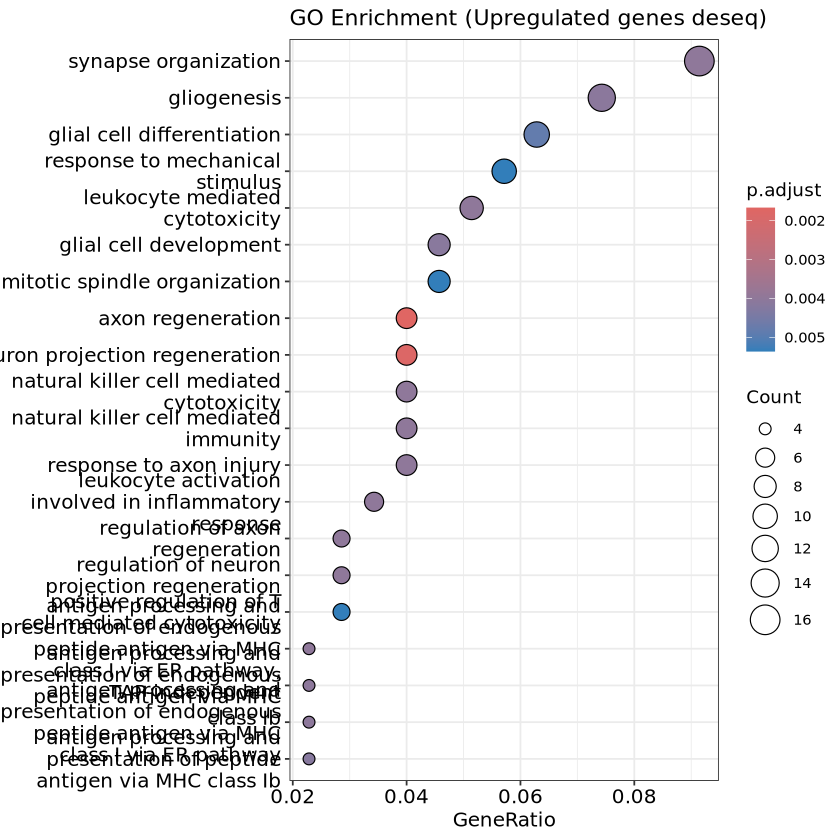

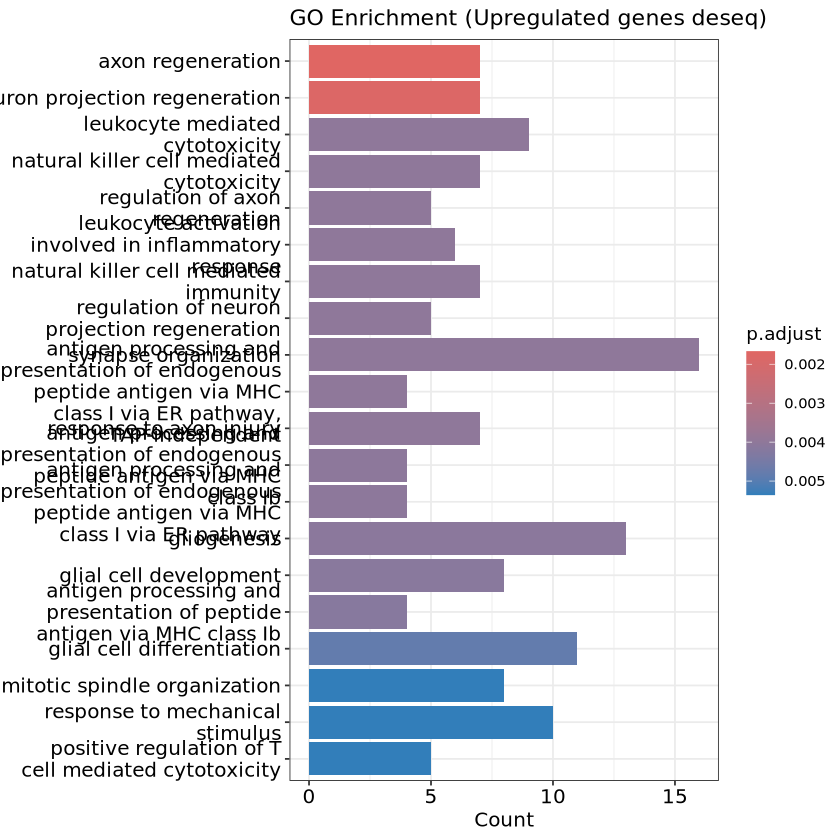

In [ ]:
dotplot(ego_result_up_deseq, showCategory = 20, title = "GO Enrichment (Upregulated genes deseq)")
barplot(ego_result_up_deseq, showCategory = 20, title = "GO Enrichment (Upregulated genes deseq)")